# Multi-Ingredient Detection

Detect multiple ingredients in one image using:
- **Generic object detection** (finds objects)
- **CLIP** (identifies what each object is)

**No dataset or training needed!**

In [ ]:
# Install packages
!pip install transformers torch pillow opencv-python -q

In [1]:
from transformers import CLIPProcessor, CLIPModel, DetrImageProcessor, DetrForObjectDetection
from PIL import Image, ImageDraw
import torch
import pandas as pd
from pathlib import Path

In [2]:
# Load models (both pre-trained, no dataset needed!)
print("Loading models...\n")

# 1. DETR - Generic object detector (finds "things" in image)
print("1. Loading DETR for object detection...")
detr_processor = DetrImageProcessor.from_pretrained("facebook/detr-resnet-50")
detr_model = DetrForObjectDetection.from_pretrained("facebook/detr-resnet-50")
print("   ✓ DETR loaded (detects objects without training)\n")

# 2. CLIP - Ingredient classifier (identifies what each object is)
print("2. Loading CLIP for ingredient identification...")
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
print("   ✓ CLIP loaded (recognizes ingredients)\n")

print("="*80)
print("✓ Both models ready! No training or dataset needed.")
print("="*80)

Loading models...

1. Loading DETR for object detection...


c:\Users\Champion\anaconda3\envs\pytorch_cuda\Lib\site-packages\torch\nn\modules\module.py:2409: UserWarning: for conv1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
c:\Users\Champion\anaconda3\envs\pytorch_cuda\Lib\site-packages\torch\nn\modules\module.py:2409: UserWarning: for bn1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
c:\Users\Champion\anaconda3\envs\pytorch_cuda\Lib\site-packages\torch\nn\modules\module.py:2409: UserWarning: for bn1.bias: copying from a non-meta parameter in the checkpoint to a met

   ✓ DETR loaded (detects objects without training)

2. Loading CLIP for ingredient identification...
   ✓ CLIP loaded (recognizes ingredients)

✓ Both models ready! No training or dataset needed.


In [3]:
# Load ingredients from CSV file
CSV_PATH = Path.cwd().parent.parent / "data" / "ingredients_vocabulary.csv"

print(f"Loading ingredients from: {CSV_PATH}\n")

# Read CSV
df = pd.read_csv(CSV_PATH)

# Build ingredient list from CSV (new format: single column "Ingredient")
INGREDIENT_CANDIDATES = df['Ingredient'].tolist()

print("="*80)
print(f"✓ Loaded {len(INGREDIENT_CANDIDATES)} ingredients from CSV")
print("="*80)
print(f"\nFirst 10 ingredients:")
for i, ing in enumerate(INGREDIENT_CANDIDATES[:10], 1):
    print(f"  {i:2d}. {ing}")
print(f"  ...")
print(f"\nYou can edit the CSV file to add/remove ingredients!")
print(f"Path: {CSV_PATH}")
print("="*80)

Loading ingredients from: c:\Users\Champion\Documents\GitHub\cAIuldron\data\ingredients_vocabulary.csv

✓ Loaded 528 ingredients from CSV

First 10 ingredients:
   1. Chicken breast
   2. Chicken thigh
   3. Chicken drumstick
   4. Chicken wing
   5. Chicken liver
   6. Chicken gizzard
   7. Chicken feet
   8. Ground chicken
   9. Turkey breast
  10. Turkey thigh
  ...

You can edit the CSV file to add/remove ingredients!
Path: c:\Users\Champion\Documents\GitHub\cAIuldron\data\ingredients_vocabulary.csv


In [4]:
def detect_multiple_ingredients(image_path, confidence_threshold=0.7, ingredient_confidence=0.15):
    """
    Detect multiple ingredients in one image
    
    Process:
    1. DETR finds all objects in image (generic detection)
    2. For each object, CLIP identifies what ingredient it is
    
    Args:
        image_path: Path to image
        confidence_threshold: Minimum confidence for object detection (0-1)
        ingredient_confidence: Minimum confidence for ingredient classification (0-1)
    
    Returns:
        List of detected ingredients with bounding boxes
    """
    image = Image.open(image_path).convert('RGB')
    
    # Step 1: Detect objects with DETR
    inputs = detr_processor(images=image, return_tensors="pt")
    outputs = detr_model(**inputs)
    
    # Convert outputs to bounding boxes
    target_sizes = torch.tensor([image.size[::-1]])
    results = detr_processor.post_process_object_detection(
        outputs, 
        target_sizes=target_sizes, 
        threshold=confidence_threshold
    )[0]
    
    detected_ingredients = []
    
    # Step 2: For each detected object, identify ingredient with CLIP
    for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
        box_coords = [int(i) for i in box.tolist()]
        x1, y1, x2, y2 = box_coords
        
        # Crop object from image
        cropped = image.crop((x1, y1, x2, y2))
        
        # Use CLIP to identify ingredient
        clip_inputs = clip_processor(
            text=INGREDIENT_CANDIDATES,
            images=cropped,
            return_tensors="pt",
            padding=True
        )
        
        with torch.no_grad():
            clip_outputs = clip_model(**clip_inputs)
        
        probs = clip_outputs.logits_per_image.softmax(dim=1)[0]
        top_prob, top_idx = probs.max(0)
        
        # Only keep if confidence is high enough
        if top_prob.item() >= ingredient_confidence:
            detected_ingredients.append({
                'ingredient': INGREDIENT_CANDIDATES[top_idx],
                'confidence': top_prob.item(),
                'bbox': box_coords,
                'detection_confidence': score.item()
            })
    
    return detected_ingredients

In [5]:
def visualize_detections(image_path, detections):
    """Draw bounding boxes and labels on image"""
    image = Image.open(image_path)
    draw = ImageDraw.Draw(image)
    
    for det in detections:
        x1, y1, x2, y2 = det['bbox']
        
        # Draw box
        draw.rectangle([x1, y1, x2, y2], outline="red", width=3)
        
        # Draw label
        label = f"{det['ingredient']} ({det['confidence']:.0%})"
        draw.text((x1, y1-20), label, fill="red")
    
    return image

## Test Multi-Ingredient Detection

Testing: test.jpeg

✓ Found 3 ingredient(s)

--------------------------------------------------------------------------------
1. Chicken breast
   Confidence: 45.1%
   Bounding box: [43, 133, 545, 584]

2. Chicken breast
   Confidence: 39.4%
   Bounding box: [0, 1, 850, 594]

3. Pork kidney
   Confidence: 16.6%
   Bounding box: [371, 65, 822, 567]



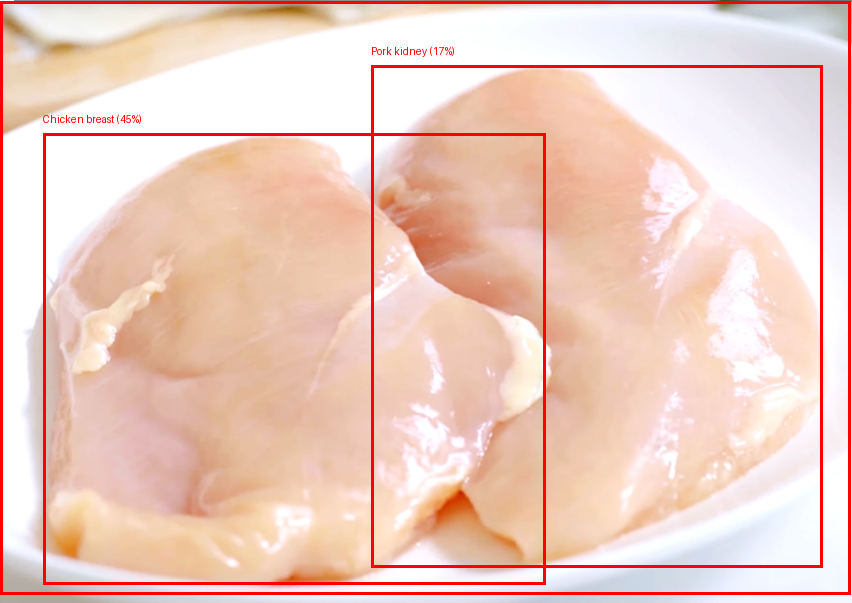

In [6]:
# Test with your image
IMAGE_PATH = Path.cwd().parent.parent / "data" / "test_images" / "test.jpeg"

print(f"Testing: {IMAGE_PATH.name}")
print("="*80)

detections = detect_multiple_ingredients(
    IMAGE_PATH,
    confidence_threshold=0.7,  # How confident DETR should be about finding objects
    ingredient_confidence=0.15  # How confident CLIP should be about ingredient type
)

print(f"\n✓ Found {len(detections)} ingredient(s)\n")
print("-"*80)

for i, det in enumerate(detections, 1):
    print(f"{i}. {det['ingredient']}")
    print(f"   Confidence: {det['confidence']:.1%}")
    print(f"   Bounding box: {det['bbox']}")
    print()

# Visualize
if detections:
    result_image = visualize_detections(IMAGE_PATH, detections)
    display(result_image)

## Alternative: Simple Whole-Image Detection

If your images typically contain just 1 main ingredient, use the simpler CLIP-only approach:

In [ ]:
# Simpler approach for single-ingredient images
def detect_single_ingredient(image_path):
    """Fast detection for images with one main ingredient"""
    image = Image.open(image_path).convert('RGB')
    
    inputs = clip_processor(
        text=INGREDIENT_CANDIDATES,
        images=image,
        return_tensors="pt",
        padding=True
    )
    
    with torch.no_grad():
        outputs = clip_model(**inputs)
    
    probs = outputs.logits_per_image.softmax(dim=1)[0]
    top_prob, top_idx = probs.max(0)
    
    return {
        'ingredient': INGREDIENT_CANDIDATES[top_idx],
        'confidence': top_prob.item()
    }

# Test
result = detect_single_ingredient(IMAGE_PATH)
print(f"Single-ingredient detection: {result['ingredient']} ({result['confidence']:.1%})")

## Which Approach to Use?

### Single-Ingredient Detection (CLIP only)
- ✅ **Faster** (~1 second)
- ✅ **Simpler** code
- ✅ **Better for** images with one main ingredient
- ❌ Can only detect one ingredient per image

### Multi-Ingredient Detection (DETR + CLIP)
- ✅ **Detects multiple** ingredients in one image
- ✅ **Gives bounding boxes** for each ingredient
- ✅ **Better for** complex scenes with many items
- ❌ Slower (~3-5 seconds)
- ❌ More complex

### Recommendation:
Start with **single-ingredient detection**. If users often upload images with multiple ingredients, switch to multi-ingredient.